<a href="https://colab.research.google.com/github/davesagit123/blank-app/blob/main/Multi_Frontier_Efficiency_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Horse Performance Ensemble: Multi-Frontier Efficiency Analysis
This notebook explores horse racing data using four normalization methods (DEA, SFA, Min-Max, Tukey) to create a robust 'Combined Score' for performance evaluation.

# Horse Performance Ensemble: Multi-Frontier Efficiency Analysis
This notebook explores horse racing data using four normalization methods (DEA, SFA, Min-Max, Tukey) to create a robust 'Combined Score' for performance evaluation.

In [3]:

import numpy as np
import pandas as pd

# 1. Input your exact sample data for the experiment structure
raw_data = """
Tab	Horse	DOD	Em	PP
1	FOREIGN PRESS	-13.5	0	7
2	GET READY LASS	-0.5	7.5	8
3	POINT VEGA	2.5	2	9.5
4	ALL ADORE	-5	6.5	7.5
5	DRAGONNE ROUGE	0.5	3.5	17
6	TOO HOT TO TORQUE	9.5	3.5	26
7	LUVA FLUTTA	3.5	12.5	81
8	HAND IN HAND	10.5	9.5	17
9	JIMMY'S BROTHER	-4	4.5	5
10	RACKETEER	5.5	3.5	5
11	MISS FUNNY HONEY	12.5	9.5	67
13	NATURALLY LIT	-7	8	51
15	SPIRIT OF BARTY	3.5	8.5	34
16	OVER SPRAY	14	8	17
17	SPIES ON	6	17	126
"""

# Parse the data into a clean DataFrame
import io
df_sample = pd.read_csv(io.StringIO(raw_data.strip()), sep="\t")
df_sample = df_sample.drop(columns=['Em']) # Drop EM as requested

def simulate_100_races_from_sample(base_df, num_races=100):
    """Simulates 100 races by adding variation to your actual sample data."""
    all_races = []
    for race_id in range(1, num_races + 1):
        race_df = base_df.copy()
        race_df['race_id'] = race_id

        # Add slight realistic noise to simulate 100 different fields/days
        race_df['DOD'] = race_df['DOD'] + np.random.normal(0, 0.2, len(race_df))
        race_df['PP'] = np.clip(race_df['PP'] + np.random.normal(0, 1.5, len(race_df)), 1.01, 200)

        # Determine a mock winner based heavily on low DOD and low PP
        winning_score = (-1 * race_df['DOD']) + (20 / race_df['PP']) + np.random.normal(0, 2, len(race_df))
        winner_idx = winning_score.idxmax()
        race_df['winner'] = 0
        race_df.loc[winner_idx, 'winner'] = 1

        all_races.append(race_df)
    return pd.concat(all_races, ignore_index=True)

# Generate the 100-race dataset
df = simulate_100_races_from_sample(df_sample, 100)

# 2. Correctly transform metrics so HIGHER numbers = BETTER horses
# For DOD: Use max value subtraction because DOD has zero and negative numbers
# (e.g., if max DOD is 4, then a DOD of -1.5 becomes: 4 - (-1.5) = 5.5 (Now the best/highest value))
df['transformed_DOD'] = df.groupby('race_id')['DOD'].transform(lambda x: x.max() - x)
df['implied_prob_PP'] = 1 / df['PP']

# Initialize methods and tracking metrics
methods = ['dea', 'sfa_pseudo', 'min_max', 'tukey']
target_metrics = ['transformed_DOD', 'implied_prob_PP']

for m in target_metrics:
    for method in methods:
        df[f'{method}_{m}'] = 0.0

# 3. Apply Frontier and Ratio Calculations per Race
for race_id, group in df.groupby('race_id'):
    idx = group.index

    for m in target_metrics:
        X = group[m].values

        # --- Method 1: Data Envelopment Analysis (DEA / Strict Leader) ---
        leader = np.max(X)
        df.loc[idx, f'dea_{m}'] = X / leader if leader != 0 else 0

        # --- Method 2: Pseudo-Stochastic Frontier Analysis (SFA) ---
        frontier = np.mean(X) + np.std(X)
        df.loc[idx, f'sfa_pseudo_{m}'] = np.clip(X / frontier, 0, 1.0) if frontier != 0 else 0

        # --- Method 3: Distance to Frontier (Min-Max Scaling) ---
        x_min, x_max = np.min(X), np.max(X)
        if x_max != x_min:
            df.loc[idx, f'min_max_{m}'] = (X - x_min) / (x_max - x_min)
        else:
            df.loc[idx, f'min_max_{m}'] = 1.0

        # --- Method 4: Tukey's Lower/Upper Fence Ratio ---
        q1, q3 = np.percentile(X, 25), np.percentile(X, 75)
        iqr = q3 - q1
        fence = q3 + (1.5 * iqr) if iqr > 0 else np.max(X)
        df.loc[idx, f'tukey_{m}'] = X / fence if fence != 0 else 0

# 4. Print Experiment Evaluation
print("=== GOOGLE COLAB EXPERIMENT RESULTS ===")
print("The ratio tracks how closely winners/losers score to the fence line.\n")

winners = df[df['winner'] == 1]
losers = df[df['winner'] == 0]

for m in target_metrics:
    label = "DOD (Lower is Better)" if m == 'transformed_DOD' else "PP Market (Lower Odds Better)"
    print(f"\nTarget Metric: {label}")
    print("-" * 65)
    for method in methods:
        col = f'{method}_{m}'
        w_score = winners[col].mean()
        l_score = losers[col].mean()
        # Calculate the performance gap between winners and the field
        gap = w_score - l_score
        print(f"[{method.upper():10}] Winner Ratio: {w_score:.3f} | Loser Ratio: {l_score:.3f} | Score Gap: {gap:+.3f}")




=== GOOGLE COLAB EXPERIMENT RESULTS ===
The ratio tracks how closely winners/losers score to the fence line.


Target Metric: DOD (Lower is Better)
-----------------------------------------------------------------
[DEA       ] Winner Ratio: 1.000 | Loser Ratio: 0.375 | Score Gap: +0.625
[SFA_PSEUDO] Winner Ratio: 1.000 | Loser Ratio: 0.537 | Score Gap: +0.463
[MIN_MAX   ] Winner Ratio: 1.000 | Loser Ratio: 0.375 | Score Gap: +0.625
[TUKEY     ] Winner Ratio: 0.881 | Loser Ratio: 0.330 | Score Gap: +0.551

Target Metric: PP Market (Lower Odds Better)
-----------------------------------------------------------------
[DEA       ] Winner Ratio: 0.638 | Loser Ratio: 0.329 | Score Gap: +0.310
[SFA_PSEUDO] Winner Ratio: 0.882 | Loser Ratio: 0.452 | Score Gap: +0.430
[MIN_MAX   ] Winner Ratio: 0.627 | Loser Ratio: 0.306 | Score Gap: +0.321
[TUKEY     ] Winner Ratio: 0.535 | Loser Ratio: 0.283 | Score Gap: +0.252


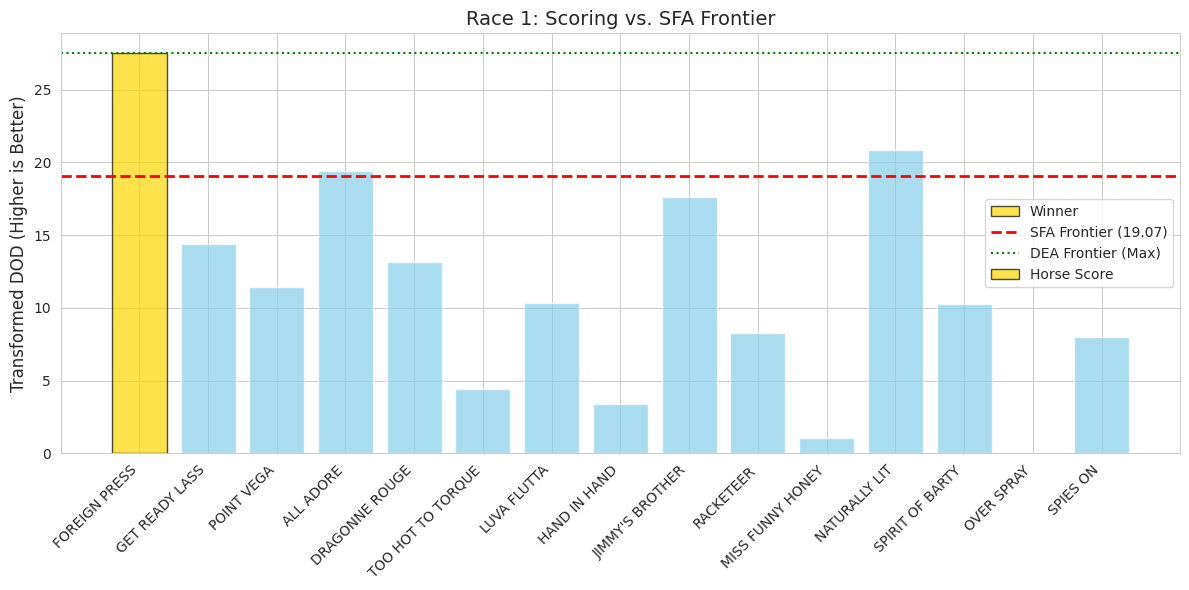

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select one race to visualize
sample_race_id = 1
race_data = df[df['race_id'] == sample_race_id].copy()

# Set up the visualization
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# We will plot the Transformed DOD scores
# Sort by horse number for consistent display
race_data = race_data.sort_values('Tab')

# Plot the scores
bars = plt.bar(race_data['Horse'], race_data['transformed_DOD'], color='skyblue', alpha=0.7, label='Horse Score')

# Highlight the winner
winner_name = race_data[race_data['winner'] == 1]['Horse'].values[0]
winner_idx = list(race_data['Horse']).index(winner_name)
bars[winner_idx].set_color('gold')
bars[winner_idx].set_edgecolor('black')
bars[winner_idx].set_label('Winner')

# Calculate and Draw the SFA Frontier line
# Frontier = Mean + 1 StdDev
mean_val = race_data['transformed_DOD'].mean()
std_val = race_data['transformed_DOD'].std()
sfa_frontier = mean_val + std_val

plt.axhline(y=sfa_frontier, color='red', linestyle='--', linewidth=2, label=f'SFA Frontier ({sfa_frontier:.2f})')
plt.axhline(y=race_data['transformed_DOD'].max(), color='green', linestyle=':', label='DEA Frontier (Max)')

plt.title(f'Race {sample_race_id}: Scoring vs. SFA Frontier', fontsize=14)
plt.ylabel('Transformed DOD (Higher is Better)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd

# 1. Define the methods we want to aggregate
score_cols = [
    'sfa_pseudo_transformed_DOD',
    'dea_transformed_DOD',
    'min_max_transformed_DOD',
    'tukey_transformed_DOD'
]

# 2. Aggregate results per horse across all simulations
horse_summary = df.groupby('Horse').agg({
    'winner': 'sum',
    'sfa_pseudo_transformed_DOD': 'mean',
    'dea_transformed_DOD': 'mean',
    'min_max_transformed_DOD': 'mean',
    'tukey_transformed_DOD': 'mean',
    'DOD': 'mean'
}).reset_index()

# 3. Calculate a Combined Score (Average of all 4 methods)
horse_summary['Combined_Efficiency'] = horse_summary[score_cols].mean(axis=1)

# 4. Rename for display
horse_summary.columns = [
    'Horse', 'Total Wins', 'SFA Ratio', 'DEA Ratio',
    'Min-Max Ratio', 'Tukey Ratio', 'Avg Raw DOD', 'Combined Score'
]

# Sort by Wins then Combined Score
horse_summary = horse_summary.sort_values(by=['Total Wins', 'Combined Score'], ascending=False)

print("=== COMPREHENSIVE HORSE EFFICIENCY SUMMARY (100 RACES) ===")
# Display with a heatmap to easily spot the 'Frontier' horses
display(horse_summary.style.background_gradient(cmap='YlGn', subset=['Total Wins', 'Combined Score', 'SFA Ratio', 'DEA Ratio']))

=== COMPREHENSIVE HORSE EFFICIENCY SUMMARY (100 RACES) ===


,Horse,Total Wins,SFA Ratio,DEA Ratio,Min-Max Ratio,Tukey Ratio,Avg Raw DOD,Combined Score
2,FOREIGN PRESS,100,1.000000,1.000000,1.000000,0.880511,-13.501407,0.970128
8,NATURALLY LIT,0,1.000000,0.763052,0.763052,0.671840,-6.990798,0.799486
0,ALL ADORE,0,0.997926,0.690431,0.690431,0.607900,-4.995684,0.746672
5,JIMMY'S BROTHER,0,0.953273,0.654319,0.654319,0.576050,-4.003931,0.709490
3,GET READY LASS,0,0.767342,0.526699,0.526699,0.463677,-0.498143,0.571104
1,DRAGONNE ROUGE,0,0.713149,0.489505,0.489505,0.431001,0.523567,0.530790
10,POINT VEGA,0,0.606658,0.416407,0.416407,0.366648,2.531531,0.451530
6,LUVA FLUTTA,0,0.555743,0.381466,0.381466,0.335874,3.490948,0.413637
13,SPIRIT OF BARTY,0,0.555204,0.381099,0.381099,0.335556,3.501187,0.413239
11,RACKETEER,0,0.448724,0.308007,0.308007,0.271204,5.508726,0.333986
